# Método do Cotovelo para o Dataset Dry Bean (KMeans)

Este notebook permite analisar o número ideal de clusters para o dataset Dry Bean utilizando o método do cotovelo com KMeans.

Tamanho do dataset original: 13611 amostras, 17 colunas
Tamanho do dataset balanceado: 24822 amostras, 17 colunas


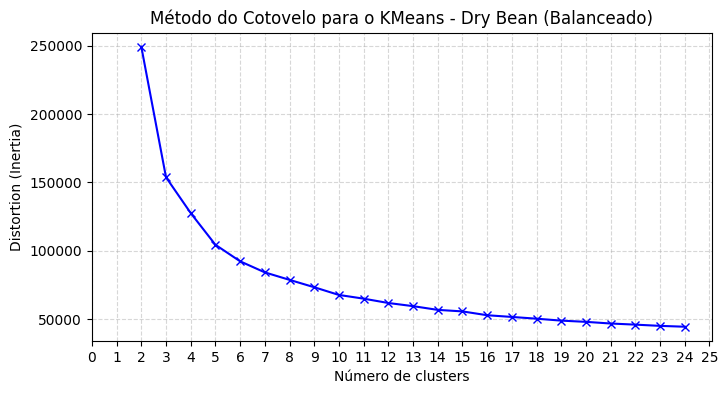

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# Carregamento do dataset Dry Bean
# O arquivo deve estar em '../data/DryBeanDataset/Dry_Bean_Dataset.xlsx'
drybean_df = pd.read_excel('../data/DryBeanDataset/Dry_Bean_Dataset.xlsx')

# Exibe o tamanho do dataset original
print(f"Tamanho do dataset original: {drybean_df.shape[0]} amostras, {drybean_df.shape[1]} colunas")

# Balanceamento por oversampling (todas as classes terão o mesmo número de exemplos da classe majoritária)
max_count = drybean_df['Class'].value_counts().max()
drybean_df_balanced = pd.DataFrame()
for label in drybean_df['Class'].unique():
    df_class = drybean_df[drybean_df['Class'] == label]
    df_upsampled = resample(df_class, replace=True, n_samples=max_count, random_state=42)
    drybean_df_balanced = pd.concat([drybean_df_balanced, df_upsampled])
drybean_df_balanced = drybean_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Exibe o tamanho do dataset após balanceamento
print(f"Tamanho do dataset balanceado: {drybean_df_balanced.shape[0]} amostras, {drybean_df_balanced.shape[1]} colunas")

# Separa features e alvo
X = drybean_df_balanced.drop('Class', axis=1).values
# Normalização dos dados
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Método do cotovelo
K = range(2, 25)
distortions = []
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    distortions.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, distortions, 'bx-')
plt.xlabel('Número de clusters')
plt.ylabel('Distortion (Inertia)')
plt.title('Método do Cotovelo para o KMeans - Dry Bean (Balanceado)')
plt.xticks(np.arange(0, 26, 1))
plt.grid(True, which='both', axis='both', linestyle='--', alpha=0.5)
plt.savefig('../img/kmeans_drybean_balance_elbow.png')
plt.show()